## Задание 1. (1 балл)

Посчитайте частоты для 5-грамм в корпусе lenta.txt. двумя способами:  
1) Текст токенизируется в один сплошной список токенов и нграммы считаются по всем токенам без учета границ предложений
2) Текст разбивается на предложения, а каждое предложение на токены; нграммы собираются с учетом границ предложений 
    
Найдите различия между топ 100 нграммов для первого и второго способов

In [11]:
import spacy
from collections import Counter

with open("lenta.txt", "r", encoding="utf-8") as f:
    text = f.read()

nlp = spacy.blank("ru")
nlp.add_pipe("sentencizer")

nlp.max_length = len(text) + 1

doc = nlp(text)

# СПОСОБ 1
# Все токены объединены в один список.
# Границы предложений НЕ учитываются.

tokens = [
    token.text.lower()
    for token in doc
    if not token.is_space
]

ngrams_all = [
    tuple(tokens[i:i+5])
    for i in range(len(tokens) - 4)
]

freq_all = Counter(ngrams_all)

top100_all = freq_all.most_common(100)


# СПОСОБ 2
# Сначала разбиваем текст на предложения.
# 5-грамма не может пересекать границу предложения.

ngrams_sentences = []

for sent in doc.sents:
    sent_tokens = [
        token.text.lower()
        for token in sent
        if not token.is_space
    ]

    for i in range(len(sent_tokens) - 4):
        ngram = tuple(sent_tokens[i:i+5])
        ngrams_sentences.append(ngram)

freq_sentences = Counter(ngrams_sentences)

top100_sentences = freq_sentences.most_common(100)


# СРАВНЕНИЕ TOP-100

set_all = set(ngram for ngram, freq in top100_all)
set_sentences = set(ngram for ngram, freq in top100_sentences)

only_all = set_all - set_sentences
only_sentences = set_sentences - set_all
common = set_all & set_sentences

print("Токенов:", len(tokens))
print("Предложений:", len(list(doc.sents)))

print("Уникальных 5-грамм, способ 1:", len(freq_all))
print("Уникальных 5-грамм, способ 2:", len(freq_sentences))

print("\nОбщие 5-граммы в Top-100:", len(common))
print("Только способ 1:", len(only_all))
print("Только способ 2:", len(only_sentences))


print("\n=== Только способ 1 ===")

rank_all = {
    ngram: (rank, freq)
    for rank, (ngram, freq) in enumerate(top100_all, 1)
}

for ngram in sorted(only_all, key=lambda x: rank_all[x][0]):
    rank, freq = rank_all[ngram]
    print(rank, freq, " ".join(ngram))


print("\n=== Только способ 2 ===")

rank_sentences = {
    ngram: (rank, freq)
    for rank, (ngram, freq) in enumerate(top100_sentences, 1)
}

for ngram in sorted(only_sentences, key=lambda x: rank_sentences[x][0]):
    rank, freq = rank_sentences[ngram]
    print(rank, freq, " ".join(ngram))


# Проверяем, изменились ли частоты общих 5-грамм

print("\n=== Общие 5-граммы с разными частотами ===")

for ngram in sorted(common):
    freq1 = freq_all[ngram]
    freq2 = freq_sentences[ngram]

    if freq1 != freq2:
        print(
            " ".join(ngram),
            "| способ 1:", freq1,
            "| способ 2:", freq2
        )

<class 'ModuleNotFoundError'>: No module named 'spacy'

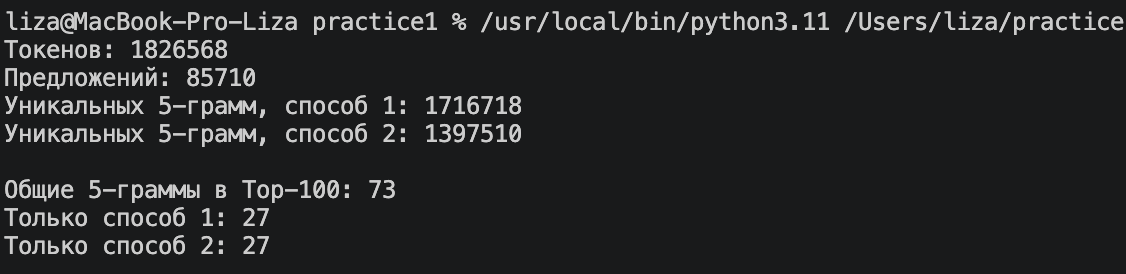

## Задание 2. (1 балл)

Найдите какую-то инетересную (по вашему мнению) закономерность на https://books.google.com/ngrams/ для русского языка (с 1990 по 2022)

Вставьте сюда скриншот

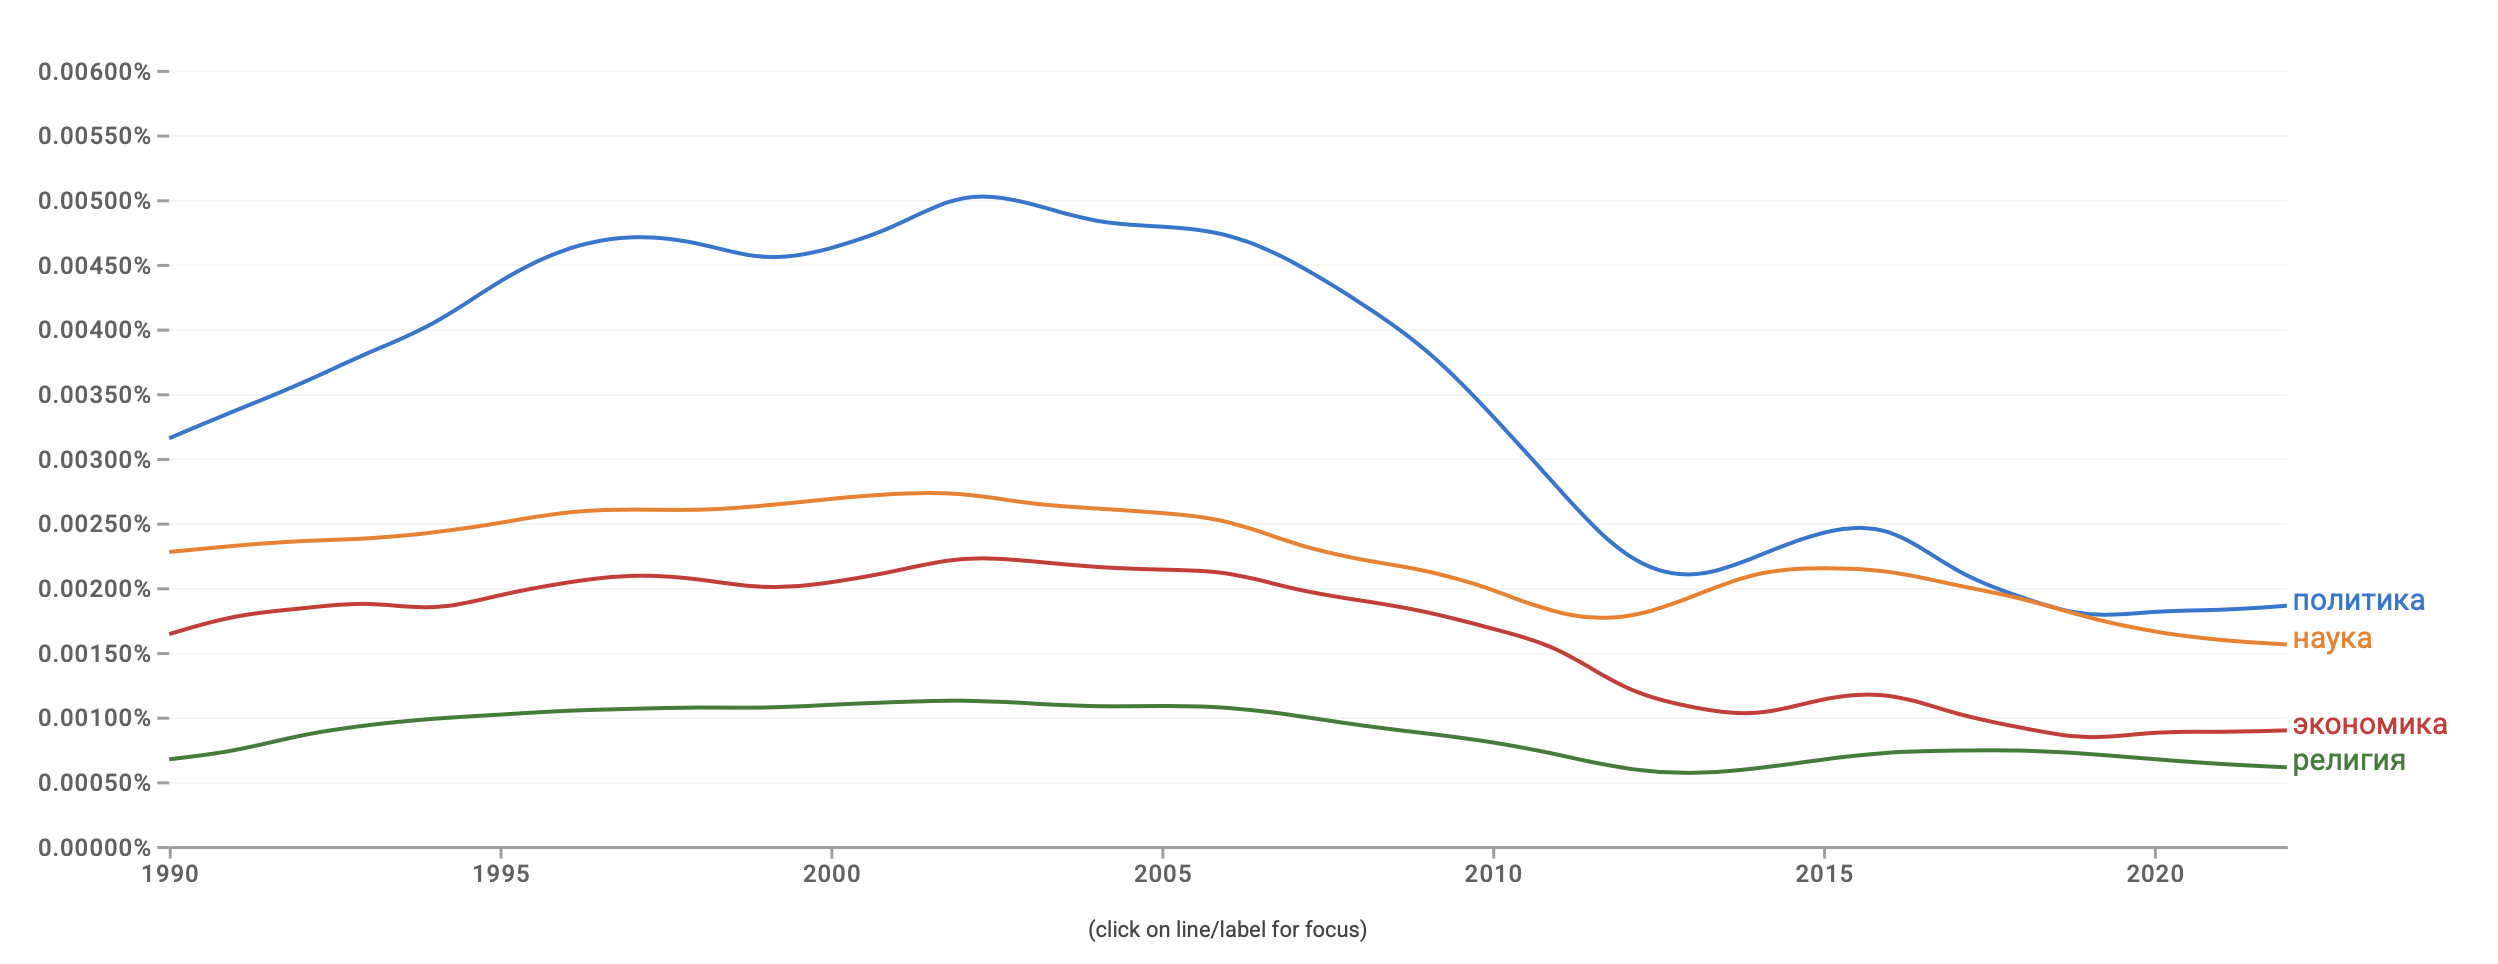

## Заданиe 3 (1 балл)

В семинаре мы использовали Dice coefficient (`score = 2 * bigram_count/((word_count_a+word_count_b))`) для нахождения коллокаций. 
Но самая известная метрика для этого другая - [PMI](https://en.wikipedia.org/wiki/Pointwise_mutual_information). Имплементируйте скоринг с помощью этой метрики и сравните результаты с Dice на топ 30 биграмах. 
Используйте логарифмы для работы с вероятностями. 

In [ ]:
def scorer_pmi(*args):
    try:
        score = ...
    except ZeroDivisionError:
        return 0
    return score

In [ ]:
import math
from collections import Counter
import spacy

with open("lenta.txt", "r", encoding="utf-8") as f:
    text = f.read()

nlp = spacy.blank("ru")
nlp.max_length = len(text) + 1

doc = nlp(text)

tokens = [
    token.text.lower()
    for token in doc
    if not token.is_space
]

print("Количество токенов:", len(tokens))

word_counts = Counter(tokens)

bigrams = [
    (tokens[i], tokens[i + 1])
    for i in range(len(tokens) - 1)
]

bigram_counts = Counter(bigrams)

total_word_count = len(tokens)

# Dice coefficient

def scorer_dice(*args):
    try:
        bigram_count, word_count_a, word_count_b = args

        score = (
            2 * bigram_count
            / (word_count_a + word_count_b)
        )

    except ZeroDivisionError:
        return 0

    return score

# 5. PMI

def scorer_pmi(*args):
    try:
        bigram_count, word_count_a, word_count_b = args

        # P(a,b)
        p_ab = bigram_count / (total_word_count - 1)

        # P(a)
        p_a = word_count_a / total_word_count

        # P(b)
        p_b = word_count_b / total_word_count

        # PMI = log(P(a,b) / (P(a) * P(b))

        score = (
            math.log(p_ab)
            - math.log(p_a)
            - math.log(p_b)
        )

    except ZeroDivisionError:
        return 0

    return score


# Считаем обе метрики для всех биграмм

dice_scores = []
pmi_scores = []

for (word_a, word_b), count in bigram_counts.items():

    word_count_a = word_counts[word_a]
    word_count_b = word_counts[word_b]

    dice = scorer_dice(
        count,
        word_count_a,
        word_count_b
    )

    pmi = scorer_pmi(
        count,
        word_count_a,
        word_count_b
    )

    dice_scores.append(
        ((word_a, word_b), count, dice)
    )

    pmi_scores.append(
        ((word_a, word_b), count, pmi)
    )

top30_dice = sorted(
    dice_scores,
    key=lambda x: x[2],
    reverse=True
)[:30]

top30_pmi = sorted(
    pmi_scores,
    key=lambda x: x[2],
    reverse=True
)[:30]

print("\n" + "=" * 70)
print("TOP-30 BIGRAMS BY DICE")
print("=" * 70)

for rank, (bigram, count, score) in enumerate(
    top30_dice, 1
):
    print(
        f"{rank:2}. "
        f"{bigram[0]} {bigram[1]:30} "
        f"freq={count:4} "
        f"Dice={score:.6f}"
    )

print("\n" + "=" * 70)
print("TOP-30 BIGRAMS BY PMI")
print("=" * 70)

for rank, (bigram, count, score) in enumerate(
    top30_pmi, 1
):
    print(
        f"{rank:2}. "
        f"{bigram[0]} {bigram[1]:30} "
        f"freq={count:4} "
        f"PMI={score:.6f}"
    )


# Сравнение Top-30

dice_bigrams = {
    bigram
    for bigram, count, score in top30_dice
}

pmi_bigrams = {
    bigram
    for bigram, count, score in top30_pmi
}

common = dice_bigrams & pmi_bigrams
only_dice = dice_bigrams - pmi_bigrams
only_pmi = pmi_bigrams - dice_bigrams


print("\n" + "=" * 70)
print("COMPARISON")
print("=" * 70)

print("Общих биграмм:", len(common))
print("Только в Dice:", len(only_dice))
print("Только в PMI:", len(only_pmi))


print("\nОбщие биграммы:")

for bigram in common:
    print(
        f"{bigram[0]} {bigram[1]}"
    )

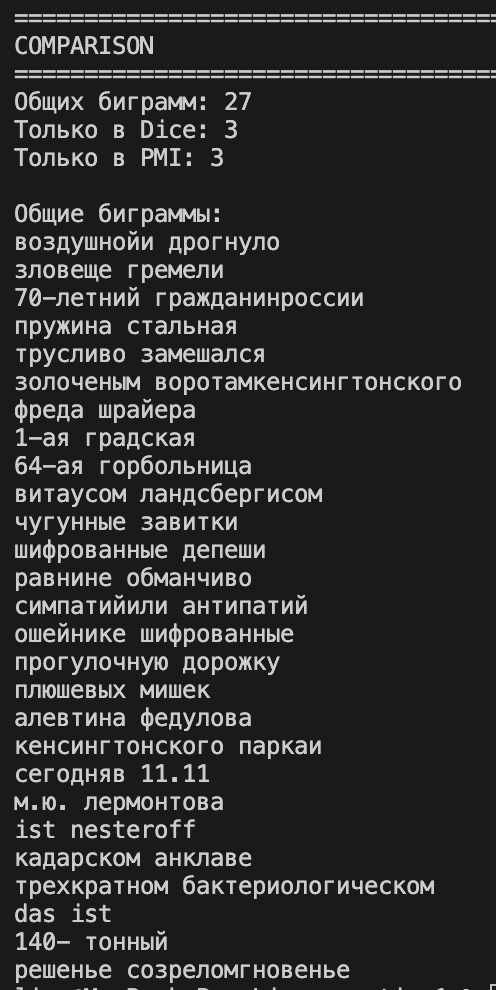

# Задание 4 (2 балл)

Шаг 1: Измените функцию merge_round так чтобы она использовала скоринг, который вы сделаете в задании выше. 
Шаг 2: Подберите параметры (min_count, n_merges, n_rounds) так чтобы получались адекватные результаты
Шаг 3: Сохраните промежуточные словари мержей и напишите функцию, которая их последовательно применяет, чтобы иметь возможности воспроизвести трансформацию на любой новом тексте 

Подберите несколько предложений, на которых функция трансформации будет склеивать хотя бы несколько слов вместе 

In [ ]:
saved_merged = []
for round_i in range(1, 10):
    sub_corpus, merges = merge_round(sub_corpus)
    saved_merged.append(merges)



def apply_merges(text, merges):
    ...
    return merged_text


new_text =  tokenize("Какой-то новый текст")
apply_merges(new_text)

В качестве скоринга для мержей использовался PMI. Были выбраны параметры min_count=20, n_merges=20, n_rounds=9. На каждом раунде выбирались 20 наиболее сильных биграмм с частотой не менее 20 и они объединялись в один токен. Все последовательности мержей сохранялись в saved_merged. Функция apply_merges() последовательно применяет сохранённые мержи к новому тексту, что позволяет воспроизвести ту же трансформацию на других текстах.

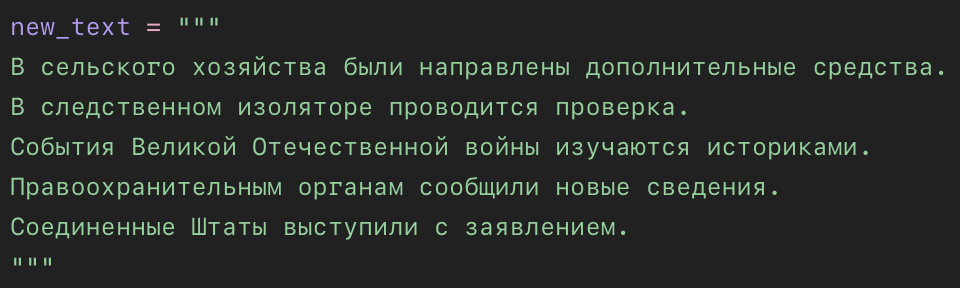

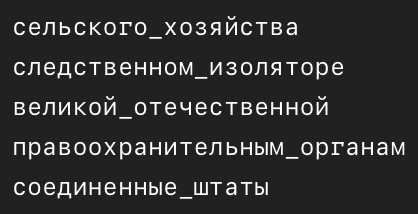

# Задание 5 (3 балла)

Напишите краткое эссе (30 - 50 предложений) в свободной форме по одной из этих статей:
1) https://news.microsoft.com/source/2026/09/09/aft-uft-and-microsoft-announce-national-ai-safety-privacy-standard-for-schools-to-protect-students-families-and-educators/ и сам целый документ https://www.aft.org/sites/default/files/media/documents/2026/NAfAI-School_AI_Privacy_Standards.pdf
2) https://bayareacurrent.com/theres-a-lot-of-cleaning-up-poop-a-depot-worker-on-the-human-labor-behind-waymos-autonomous-vehicles/

Эту часть достаточно сложно оценивать формально, но я ожидаю увидеть ваши содержательные рассуждения о написанном в статье.   
Если после прочтения вам ничего не приходит в голову, то вы можете начать со следующих вопросов: Считаете ли вы эту информацию важной/интересной/страшной/скучной/и тп? Что показалось вам наиболее важным? Почему? Считаете ли вы эту статью объективной? Какие пробелы вы видите? По вашему мнению будет ли продолжение у этих историй? В каком направлении они будут развиваться? Считаете ли вы age restriction необходимым для AI моделей? (для первой статьи) Как можно предотвращать/бороться с подобным антисоциальным поведением в автономных автомобилях? (для второй) ... 
Но это не полный и не обязательный список! Вы можете писать о всем, что вы посчитаете нужным. 

Чего точно следует избегать:
1) Не пишите саммари! Ваше эссе должно выражать ваши собственные мысли и добавлять что-то к тексту, а не заменять его.
2) Не гонитесь за полнотой! Можно и нужно опускать детали. Вы даже можете даже сфокусироваться только на каком-то одном аспекте статьи и порассуждать о нем поглубже.
3) Не отвлекайтесь на форматирование! Не используйте нумерованные списки, булет пойнты, ссылки и т.п. Напишите все как один связанный plain текст (можете разбить все на параграфы, но не более того)
4) Не объясняйте термины и понятия, не давайте определений! Считайте, что читатель знает столько же, сколько вы или же что он может погуглить.
5) Не уходите от темы! Реагируйте только на сам текст, а не на общий контекст (схожие события и работы, реакция в сотсетях и т.п). Не сравнивайте с другими статьями от того же Антропика или OpenAI.
6) Не бойтесь выражать мнение! Но либо обосновывайте его, либо описиваете свои ощущения в деталях.
7) Будьте осторожными с bias. Не списывайте все на капитализм, AI buble, AI doomerism, AI accerationalism и тому подобные слишком общие и абстрактные вещи. Не выражайте ваше личное отношение к авторам (антропику), только к содержанию статьи! 



Статья о работе сотрудников депо Waymo показалась мне интересной из-за довольно неожиданного противоречия. Когда мы видим беспилотную машину на улице, кажется, что она практически полностью работает сама. Но за этой машиной на самом деле стоит много людей, которые занимаются тем, что пассажир обычно вообще не замечает.

Мне кажется, именно это и есть самая интересная мысль статьи. Автомобиль может ехать без водителя, но это ещё не значит, что он полностью независим от людей. Кто-то должен следить за его состоянием, чистить сенсоры, заниматься программным обеспечением и решать проблемы, с которыми машина сама не справляется. Получается, что человек просто оказывается не внутри автомобиля, а где-то за его пределами. Особенно забавно и одновременно странно читать о том, чем иногда приходится заниматься сотрудникам депо. Речь идёт не только о сложных технических проблемах, но и о довольно обычной уборке. Иногда приходится убирать из машины то, что оставили пассажиры, или очищать её после неприятных ситуаций. На мой взгляд, это хорошо показывает разницу между красивым образом современных технологий и их реальной повседневной работой. Высокотехнологичная машина всё равно иногда требует довольно обычного человеческого труда.

Ещё мне запомнилась ситуация, когда несколько автомобилей сталкиваются с проблемой одновременно. Каждая машина сама по себе может вести себя достаточно осторожно, но когда таких машин становится много, появляются новые сложности. Если несколько автомобилей оказываются в ситуации, где каждый ждёт действий от другого, они могут просто остановиться и ничего не делать. Получается довольно интересная проблема: машина может быть очень осторожной и при этом не уметь нормально выйти из какой-то простой ситуации.Мне кажется, это вообще одна из главных сложностей автономных систем. В реальной жизни не всегда бывает одна правильная реакция на проблему. Иногда нужно немного нарушить привычный порядок действий, договориться с другими участниками движения или просто понять, что сейчас происходит. Человек обычно делает это довольно легко и даже не задумывается о процессе. Для машины же такая ситуация может оказаться намного сложнее.

При этом я не думаю, что статья доказывает бесполезность беспилотных автомобилей. Мне кажется, из одного интервью вообще нельзя сделать такой большой вывод. Работник депо видит только определённую часть всей системы и сам говорит о том, что не знает всего происходящего. Поэтому его опыт интересен, но он всё-таки не даёт полной картины работы Waymo.

В то же время мне показалось, что статья написана довольно критично. Автор специально обращает внимание на самые странные, неприятные и забавные ситуации. Из-за этого у читателя может сложиться впечатление, что с автомобилями постоянно что-то происходит. Возможно, в обычный день большая часть машин работает нормально и просто не создаёт никаких интересных историй для статьи. Поэтому я бы не воспринимал описанные случаи как показатель того, насколько хорошо или плохо работает вся система. Но именно такие истории и делают статью интересной. Если бы в ней рассказывалось только о технологиях, алгоритмах и технических характеристиках, она была бы намного скучнее. Здесь же появляется ощущение, что за сложной технологией стоят обычные люди, которые каждый день исправляют небольшие проблемы. Мне кажется, это помогает лучше понять, как на самом деле работают подобные системы.

После прочтения я ещё подумала о том, что будет с этой работой в будущем. Если автомобили станут лучше справляться с проблемами самостоятельно, часть обязанностей сотрудников действительно может исчезнуть. Но, скорее всего, полностью человеческое участие всё равно не исчезнет. Просто люди будут заниматься другими задачами, которые сейчас ещё не так заметны. Возможно, это вообще нормальная особенность автоматизации. Когда какая-то работа становится автоматической, человек не обязательно исчезает из процесса. Иногда он просто перемещается туда, где его присутствие становится менее заметным. В случае с Waymo пассажир видит только автомобиль, но не видит людей, которые обеспечивают его работу. Поэтому после статьи я стала немного по-другому воспринимать слово «автономный». Для меня оно теперь не означает, что машина вообще не зависит от людей. Скорее, она может самостоятельно выполнять определённую часть работы, а всё остальное обеспечивается людьми и инфраструктурой вокруг неё. И мне кажется, это более реалистичный взгляд на современные технологии.

В целом статья оставила у меня смешанное впечатление. С одной стороны, некоторые описанные ситуации выглядят довольно нелепо для технологии, которая должна быть максимально самостоятельной. С другой стороны, я не вижу в этом доказательства того, что сама идея беспилотных автомобилей не работает. Скорее, статья показывает, насколько много разных мелочей скрывается за простой поездкой пассажира из одного места в другое. Именно поэтому мне было интереснее всего читать не про сам автомобиль, а про людей, которые остаются за кадром.
